# 01. Acidic Hydrogen Evolution Reaction

We begin with the acidic hydrogen evolution reaction, which sets up the workflow the other notebooks reuse. Three methods are applied to the mechanism. The numerical method
integrates the coverage equations $\dot\theta = N\,v(\theta)$ to steady state
with a stiff (BDF) solver and makes no rate-limiting-step or quasi-equilibrium
assumption. We treat it as the reference. The quasi-steady-state approximation
(QSSA) solves the algebraic system $N\,v(\theta)=0$ directly and is exact for
the mechanisms considered. The Gillespie Monte Carlo
algorithm (GMC) propagates a finite ensemble of $N$ sites with integer
occupancies through stochastic elementary events. In the large-$N$ limit it
converges to the deterministic state and provides an assumption-free
cross-check that also resolves finite-size fluctuations.

We then construct the designed rate-limiting-step (RLS) cases used in the
accompanying paper: parameter sets that share identical thermodynamics
($\prod_i K_i = 1$, so every case has the same equilibrium potential) but
differ only in which elementary step is kinetically slow. Comparing their Tafel
responses isolates the kinetic contribution to the slope.

The notebook is run from the repository's `tutorials/` folder so that the
imports resolve. Please note that `numpy`, `scipy`, and `matplotlib` are required.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

import core          # parameterized microkinetics engine (the methods)
import mechanisms as M   # the mechanisms and designed-RLS cases of the paper

## The mechanism

$$\text{Volmer:}\quad *+\mathrm{H^+}+e^-\rightleftharpoons \mathrm{H^*}$$
$$\text{Heyrovsky:}\quad \mathrm{H^*}+\mathrm{H^+}+e^-\rightleftharpoons *+\mathrm{H_2}$$
$$\text{Tafel:}\quad 2\,\mathrm{H^*}\rightleftharpoons 2\,*+\mathrm{H_2}\;\;\text{(chemical)}$$

The steps are written in the cathodic (forward) direction (`direction=-1`) with
unit bulk activities. The walkthrough uses the Volmer-RLS case of the paper:
the Volmer forward rate constant is kinetically slow ($\delta=10^{-3}$) and the
reverse constants are chosen to satisfy $K_1K_2=1$ and $K_1^2K_3=1$, which
places the overall equilibrium potential of every case at $\eta=0$. These constants are
also the defaults of the standalone scripts in the repository root.

In [2]:
mech = M.her_mechanism(**M.HER_CASES["Volmer"])
print("species:", mech.species)
print("steps:  ", mech.labels)
print("case constants:", M.HER_CASES["Volmer"])

species: ['*', 'H']
steps:   ['Volmer', 'Heyrovsky', 'Tafel']
case constants: {'k1': 0.001, 'km1': 1.0, 'k2': 1.0, 'km2': 0.001, 'k3': 1.0, 'km3': 1e-06}


## Numerical integration to steady state

The coverage equations are integrated from a clean surface until they settle.
The steady-state current, the coverages, and a local Tafel is reported.

In [3]:
etas_coarse = np.linspace(-0.02, -0.45, 12)
eta_n, j_n, th_n, b_n = core.numerical_scan(mech, etas_coarse)

print(f"{'eta/V':>8}{'j/A cm^-2':>14}{'b/mV dec^-1':>13}   coverages")
for e, jj, th, b in zip(eta_n, j_n, th_n, b_n):
    cov = "  ".join(f"{s}={t:6.3f}" for s, t in zip(mech.species, th))
    print(f"{e:8.3f}{jj:14.3e}{b:13.1f}   {cov}")

   eta/V     j/A cm^-2  b/mV dec^-1   coverages
  -0.020    -1.539e-07         43.0   *= 0.999  H= 0.001
  -0.059    -5.478e-07         96.6   *= 0.999  H= 0.001
  -0.098    -1.274e-06        113.2   *= 0.999  H= 0.001
  -0.137    -2.774e-06        117.2   *= 0.999  H= 0.001
  -0.176    -5.959e-06        118.1   *= 0.999  H= 0.001
  -0.215    -1.276e-05        118.3   *= 0.999  H= 0.001
  -0.255    -2.731e-05        118.3   *= 0.999  H= 0.001
  -0.294    -5.845e-05        118.3   *= 0.999  H= 0.001
  -0.333    -1.251e-04        118.3   *= 0.999  H= 0.001
  -0.372    -2.676e-04        118.3   *= 0.999  H= 0.001
  -0.411    -5.727e-04        118.3   *= 0.999  H= 0.001
  -0.450    -1.225e-03        118.3   *= 0.999  H= 0.001


## Quasi-steady-state approximation

The same steady state is obtained by solving $N\,v(\theta)=0$ with a root
finder, each overpotential point continued from the previous overpotential.
The comparison against the numerical points below tests the two implementations.


In [4]:
etas_dense = np.linspace(-0.02, -0.45, 160)
eta_q, j_q, th_q, b_q = core.qssa_scan(mech, etas_dense)

# agreement at the points (QSSA evaluated exactly there)
j_q_at = np.array([core.qssa_state(mech, e)[0] for e in eta_n])
print("max relative |j_QSSA - j_num| at the points:",
      np.max(np.abs((j_q_at - j_n) / j_n)))

max relative |j_QSSA - j_num|: 0.0


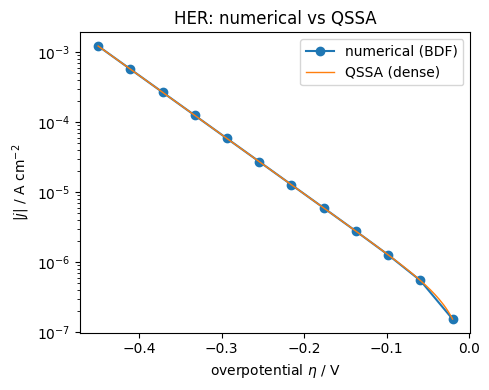

In [5]:
fig, ax = plt.subplots(figsize=(5, 4))
ax.semilogy(eta_n, np.abs(j_n), "o-", label="numerical (BDF)")
ax.semilogy(eta_q, np.abs(j_q), "-", lw=1, label="QSSA (dense)")
ax.set_xlabel(r"overpotential $\eta$ / V")
ax.set_ylabel(r"$|j|$ / A cm$^{-2}$")
ax.legend(); ax.set_title("HER: numerical vs QSSA")
fig.tight_layout(); plt.show()

## Stochastic simulation (Gillespie Monte Carlo)

The stochastic method uses $N$ discrete sites with integer occupancies,
advanced one elementary event at a time by the Gillespie algorithm.
The trajectory-averaged current converges to the deterministic valaue,
with a standard error estimated from independent trajectories.
Light settings and a few overpotentials are used here so the cell completes in seconds.
The error bars tighten as `n_sites` and `n_traj` are increased.

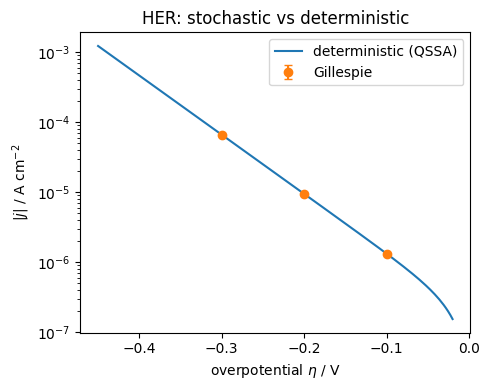

eta=-0.100 V   j=-1.325e-06 +/- 7.8e-10 A/cm^2
eta=-0.200 V   j=-9.462e-06 +/- 1.1e-08 A/cm^2
eta=-0.300 V   j=-6.618e-05 +/- 1.8e-07 A/cm^2


In [6]:
etas_gmc = np.array([-0.10, -0.20, -0.30])
eg, jg, seg, thg = core.gillespie_scan(mech, etas_gmc,
                                       n_sites=1000, n_burn=20000, n_prod=80000, n_traj=3)

fig, ax = plt.subplots(figsize=(5, 4))
ax.semilogy(eta_q, np.abs(j_q), "-", label="deterministic (QSSA)")
ax.errorbar(eg, np.abs(jg), yerr=seg, fmt="o", capsize=3, label="Gillespie")
ax.set_xlabel(r"overpotential $\eta$ / V")
ax.set_ylabel(r"$|j|$ / A cm$^{-2}$")
ax.legend(); ax.set_title("HER: stochastic vs deterministic")
fig.tight_layout(); plt.show()

for e, jj, s in zip(eg, jg, seg):
    print(f"eta={e:+.3f} V   j={jj: .3e} +/- {s:.1e} A/cm^2")

## Potentiostatic transients

The numerical method also gives the current–time response to a potential step.
From a clean surface only the Volmer step can proceed (no adsorbed H is present
yet), so the current starts at approximately half its steady value and doubles
as $\theta_\mathrm{H}$ reaches steady state.

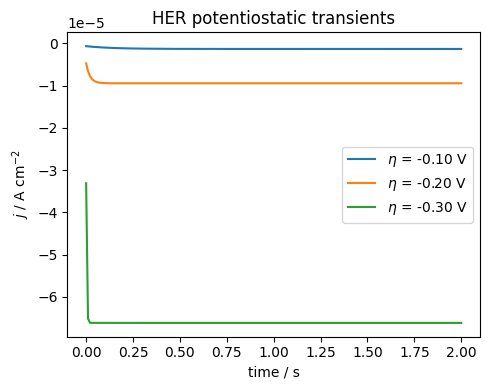

In [7]:
fig, ax = plt.subplots(figsize=(5, 4))
for e in (-0.10, -0.20, -0.30):
    t, it = core.transient(mech, e, t_end=2.0, n=200)
    ax.plot(t, it, label=fr"$\eta$ = {e:+.2f} V")
ax.set_xlabel("time / s"); ax.set_ylabel(r"$j$ / A cm$^{-2}$")
ax.legend(); ax.set_title("HER potentiostatic transients")
fig.tight_layout(); plt.show()

## Three designed RLS cases

`M.HER_CASES` holds the paper's three canonical parameter sets — Volmer-RLS,
Heyrovsky-RLS, and Tafel-RLS, with identical thermodynamics and a different
kinetically slow step in each. If the Tafel slope identified the RLS uniquely,
the three cases would be distinguishable by slope alone.

In [8]:
cases = {name: core.qssa_scan(M.her_mechanism(**kw), etas_dense)
         for name, kw in M.HER_CASES.items()}

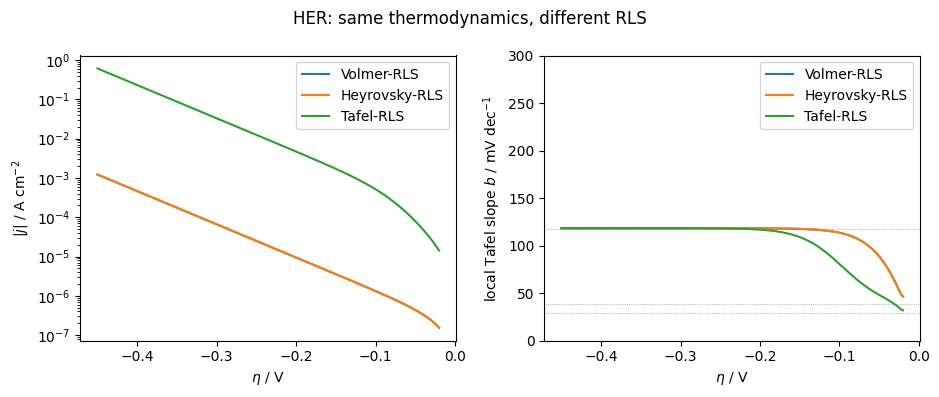

In [9]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(9.5, 4))
for name, (ee, jj, _, _) in cases.items():
    ax1.semilogy(ee, np.abs(jj), label=f"{name}-RLS")
    ax2.plot(ee, M.local_slope(ee, jj), label=f"{name}-RLS")
ax1.set_xlabel(r"$\eta$ / V"); ax1.set_ylabel(r"$|j|$ / A cm$^{-2}$"); ax1.legend()
ax2.set_xlabel(r"$\eta$ / V"); ax2.set_ylabel(r"local Tafel slope $b$ / mV dec$^{-1}$")
ax2.set_ylim(0, 300); ax2.axhline(118, color="gray", lw=0.5, ls=":")
ax2.axhline(39, color="gray", lw=0.5, ls=":"); ax2.axhline(29.5, color="gray", lw=0.5, ls=":")
ax2.legend(); fig.suptitle("HER: same thermodynamics, different RLS")
fig.tight_layout(); plt.show()

In [10]:
def slope_at(ee, jj, eta0):
    b = M.local_slope(ee, jj)
    return b[np.argmin(np.abs(ee - eta0))]

print(f"{'case':>12}{'b @ -0.05 V':>14}{'b @ -0.40 V':>14}   (mV/dec)")
for name, (ee, jj, _, _) in cases.items():
    b1, b2 = slope_at(ee, jj, -0.05), slope_at(ee, jj, -0.40)
    fmt = lambda b: f"{b:10.1f}" if b < 1e3 else "     >1000"
    print(f"{name:>12}{fmt(b1):>14}{fmt(b2):>14}")

        case   b @ -0.05 V   b @ -0.40 V   (mV/dec)
      Volmer          88.4         118.3
   Heyrovsky          88.4         118.3
       Tafel          48.0         118.3


## Summary

The three cases have different RLSs, but their Tafel slope plots do
not separate into distinct cardinal slopes. The local slope depends on the
overpotential window and on the coverage response of the non-limiting steps.
The Volmer- and Heyrovsky-RLS cases are slope-identical over the range swept
here, and all three cases converge to $\approx 120$ mV/dec at high
overpotential (i.e. they share the same limiting Tafel slope).
A measured slope therefore does not invert uniquely to an RLS assignment.
